# Tanzania Antenatal Haemoglobin Forecasting — Model Notebook
Capstone: *Predicting Follow-up Haemoglobin and Identifying Unreliable Predictions in a Tanzanian Antenatal Cohort*
Supervisor: Emmanuel Adjei

This notebook covers the ML Track deliverables for the Initial Software Demonstration:
data engineering & visualization, Stage 1 model architecture, and initial performance metrics,
run against the real dataset (Zenodo DOI `10.5281/zenodo.15309733`, file `maternal_dataset_csv.csv`,
md5 `0253d2d385dd80d6c9bb82df6b85fcc8`).


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_adapter import load_and_map
from pipeline import (
    FEATURE_COLUMNS, TARGET_COLUMN, GESTATION_VISIT2_COLUMN,
    apply_eligibility, exclusion_log, missingness_report, fixed_split,
    train_stage1_candidates, stage1_predict, mean_absolute_error, rmse,
    mean_signed_error, tree_disagreement,
)

RAW_PATH = "../data/raw/maternal_dataset_csv.csv"  # the file downloaded from Zenodo, unmodified


## 1. Load raw data and map to the model contract
The Zenodo release ships one row per woman with up to 8 antenatal visits spread across
`_v1`..`_v8`-suffixed columns (683 columns total), using field names that don't match the
protocol's clean names, and with real-world messiness (blood pressure stored as a single
"120/80"-style string, "not_checked" used as a missing-value sentinel in some numeric fields).
`data_adapter.load_and_map` performs ONLY selection, renaming, and light type-cleaning; it
does not impute or drop any rows -- that stays inside the eligibility screen below, in one place.


In [2]:
raw_mapped = load_and_map(RAW_PATH)
print(raw_mapped.shape)
raw_mapped.head()


(8817, 14)


,hb_visit1_g_dl,gestation_visit1_weeks,maternal_age_years,pregnancy_count,height_cm,weight_visit1_kg,pulse_visit1_bpm,respiratory_rate_visit1,systolic_bp_visit1,diastolic_bp_visit1,target_hb_visit2_g_dl,gestation_visit2_weeks,_source_row,_original_risk_label
0,11.0,21.0,18,1,132.0,53.0,112.0,21.0,119.0,65.0,11.4,28.0,1,high
1,10.3,25.0,18,3,149.0,54.0,NaN,103.0,104.0,68.0,11.4,31.0,2,high
2,10.3,25.0,24,1,142.0,54.0,NaN,NaN,104.0,68.0,11.4,34.0,3,high
3,8.6,20.0,18,3,159.0,48.0,99.0,NaN,125.0,65.0,12.0,27.0,4,high
4,NaN,NaN,20,1,132.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,low


## 2. Eligibility filtering
Applies the prespecified, audit-only rules: both Hb readings recorded and within 3–20 g/dL,
both gestational-week values within 1–42, and the second contact later than the first.


In [3]:
log = exclusion_log(raw_mapped)
print(log['reason'].value_counts())

eligible = apply_eligibility(raw_mapped)
print(f"Eligible paired records: {len(eligible)}")
assert len(eligible) >= 1884 + 402 + 399, "Fewer eligible records than the frozen split requires"


reason
missing_hb_reading                                                    3951
eligible                                                              2685
missing_hb_reading;gestation2_out_of_range                            1958
non_increasing_gestation                                                80
missing_hb_reading;non_increasing_gestation                             72
missing_hb_reading;gestation1_out_of_range                              45
missing_hb_reading;gestation1_out_of_range;gestation2_out_of_range      10
hb_visit2_out_of_range                                                   7
gestation2_out_of_range                                                  5
hb_visit1_out_of_range                                                   2
hb_visit1_out_of_range;hb_visit2_out_of_range                            2
Name: count, dtype: int64
Eligible paired records: 2685


## 3. Missingness among the ten permitted inputs (Table 4)

In [4]:
report = missingness_report(eligible)
report


,n_missing,pct_missing
hb_visit1_g_dl,0,0.0
gestation_visit1_weeks,0,0.0
maternal_age_years,0,0.0
pregnancy_count,0,0.0
height_cm,0,0.0
weight_visit1_kg,0,0.0
pulse_visit1_bpm,132,4.9
respiratory_rate_visit1,643,23.9
systolic_bp_visit1,18,0.7
diastolic_bp_visit1,18,0.7


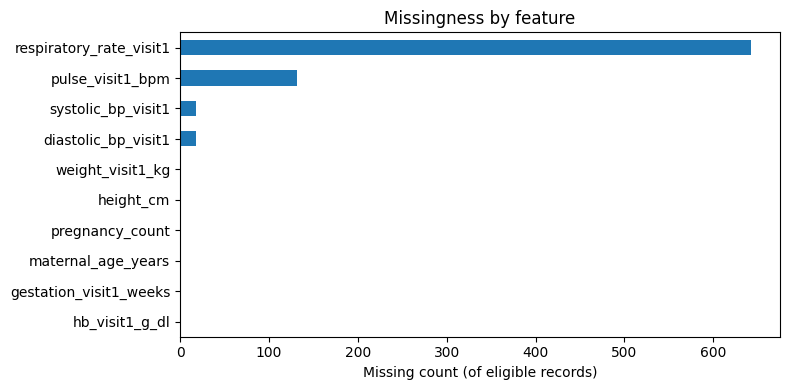

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
report['n_missing'].sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Missing count (of eligible records)')
ax.set_title('Missingness by feature')
plt.tight_layout()
plt.savefig('fig_missingness.png', dpi=150)
plt.show()


## 4. First- vs second-contact haemoglobin

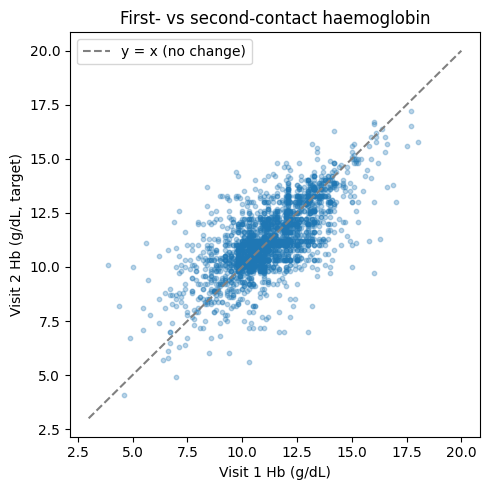

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(eligible['hb_visit1_g_dl'], eligible[TARGET_COLUMN], alpha=0.3, s=10)
lims = [3, 20]
ax.plot(lims, lims, linestyle='--', color='gray', label='y = x (no change)')
ax.set_xlabel('Visit 1 Hb (g/dL)')
ax.set_ylabel('Visit 2 Hb (g/dL, target)')
ax.set_title('First- vs second-contact haemoglobin')
ax.legend()
plt.tight_layout()
plt.savefig('fig_hb1_vs_hb2.png', dpi=150)
plt.show()


## 5. Follow-up gap distribution (weeks)

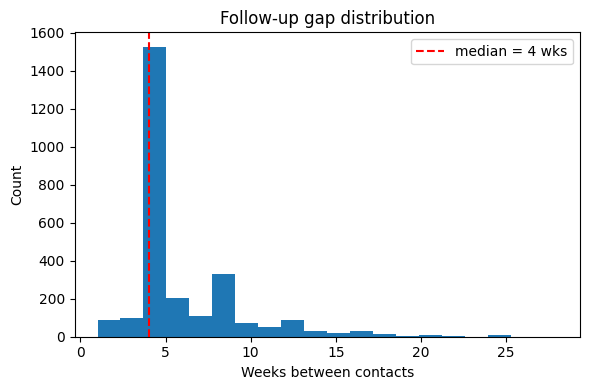

In [7]:
gap_weeks = eligible[GESTATION_VISIT2_COLUMN] - eligible['gestation_visit1_weeks']
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(gap_weeks, bins=20)
ax.axvline(gap_weeks.median(), color='red', linestyle='--', label=f'median = {gap_weeks.median():.0f} wks')
ax.set_xlabel('Weeks between contacts')
ax.set_ylabel('Count')
ax.set_title('Follow-up gap distribution')
ax.legend()
plt.tight_layout()
plt.savefig('fig_followup_gap.png', dpi=150)
plt.show()


## 6. Fixed data partitioning
Deterministic 1,884 / 402 / 399 split (train / development / reserved test).
The test partition below is **not touched again** until Week 7 of the plan.


In [8]:
train_df, dev_df, test_df = fixed_split(eligible, seed=42)
print(len(train_df), len(dev_df), len(test_df))

train_df.to_csv('../data/raw/train_frozen.csv', index=False)
dev_df.to_csv('../data/raw/dev_frozen.csv', index=False)
test_df.to_csv('../data/raw/test_frozen.csv', index=False)  # do not open again until Week 7


1884 402 399


## 7. Stage 1 — model architecture and comparison
Four candidates, grouped 3-fold cross-validation inside the training partition only:
training-median baseline, first-Hb carry-forward, ridge regression, and a compact random forest.
Selection is by training cross-validation MAE, not by peeking at the development set.


In [9]:
stage1_results = train_stage1_candidates(train_df, n_folds=3, seed=42)
for name, r in sorted(stage1_results.items(), key=lambda kv: kv[1].cv_mae):
    print(f"{name:15s}  training CV MAE = {r.cv_mae:.3f} g/dL")


random_forest    training CV MAE = 0.760 g/dL
ridge            training CV MAE = 0.802 g/dL
carry_forward    training CV MAE = 0.879 g/dL
median           training CV MAE = 1.134 g/dL


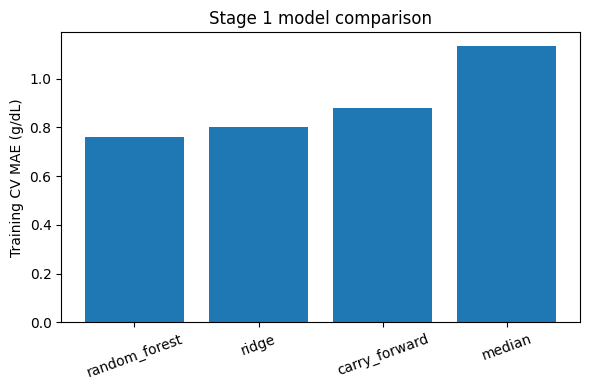

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
names = sorted(stage1_results.keys(), key=lambda n: stage1_results[n].cv_mae)
maes = [stage1_results[n].cv_mae for n in names]
ax.bar(names, maes)
ax.set_ylabel('Training CV MAE (g/dL)')
ax.set_title('Stage 1 model comparison')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('fig_stage1_comparison.png', dpi=150)
plt.show()


## 8. Initial performance metrics on the development partition
This is the **development** set only (frozen candidates compared once here); the reserved
test set is evaluated a single time later, in Week 7, per the frozen protocol.


In [11]:
rows = []
for name, r in stage1_results.items():
    pred = stage1_predict(r, dev_df)
    rows.append({
        'model': name,
        'dev_MAE': round(mean_absolute_error(dev_df[TARGET_COLUMN], pred), 3),
        'dev_RMSE': round(rmse(dev_df[TARGET_COLUMN], pred), 3),
        'dev_mean_signed_error': round(mean_signed_error(dev_df[TARGET_COLUMN], pred), 3),
    })
metrics_df = pd.DataFrame(rows).sort_values('dev_MAE').reset_index(drop=True)
metrics_df


,model,dev_MAE,dev_RMSE,dev_mean_signed_error
0,random_forest,0.793,1.095,-0.025
1,ridge,0.807,1.091,-0.016
2,carry_forward,0.926,1.308,-0.034
3,median,1.080,1.465,-0.241


## 9. Next steps (Stage 2, per the frozen timeline)
Stage 2's out-of-fold error estimator and the coverage-based equity audit are implemented in
`src/pipeline.py` (`tree_disagreement`, `mae_at_coverage`) and will be run once the frozen
Stage 1 recipe above is finalised, per Weeks 5–7 of the plan. Left for the next checkpoint
rather than rushed here, consistent with not tuning after peeking at results.
